In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import timedelta
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("All imports done")

2026-03-28 08:36:48.063684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774687008.461741      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774687008.577515      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774687009.518160      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774687009.518214      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774687009.518217      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports done


In [3]:
start_load = time.time()

interaction_data  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/interaction_data.csv')
presentations     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations.csv')
presentations_df  = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/presentations_df.csv')
ratings_matrix    = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/ratings_matrix.csv')
recommendations   = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/recommendations.csv')
user_profiles     = pd.read_csv('/kaggle/input/datasets/janvijain96/presentation-advisor-data/user_profiles.csv')

print(f"Loaded in {time.time()-start_load:.2f}s")
print(f"interaction_data : {interaction_data.shape}")
print(f"ratings_matrix   : {ratings_matrix.shape}")
print(f"recommendations  : {recommendations.shape}")
print(f"user_profiles    : {user_profiles.shape}")
print(f"presentations    : {presentations.shape}")

Loaded in 0.24s
interaction_data : (25000, 75)
ratings_matrix   : (3000, 5)
recommendations  : (100, 26)
user_profiles    : (30, 5)
presentations    : (78, 15)


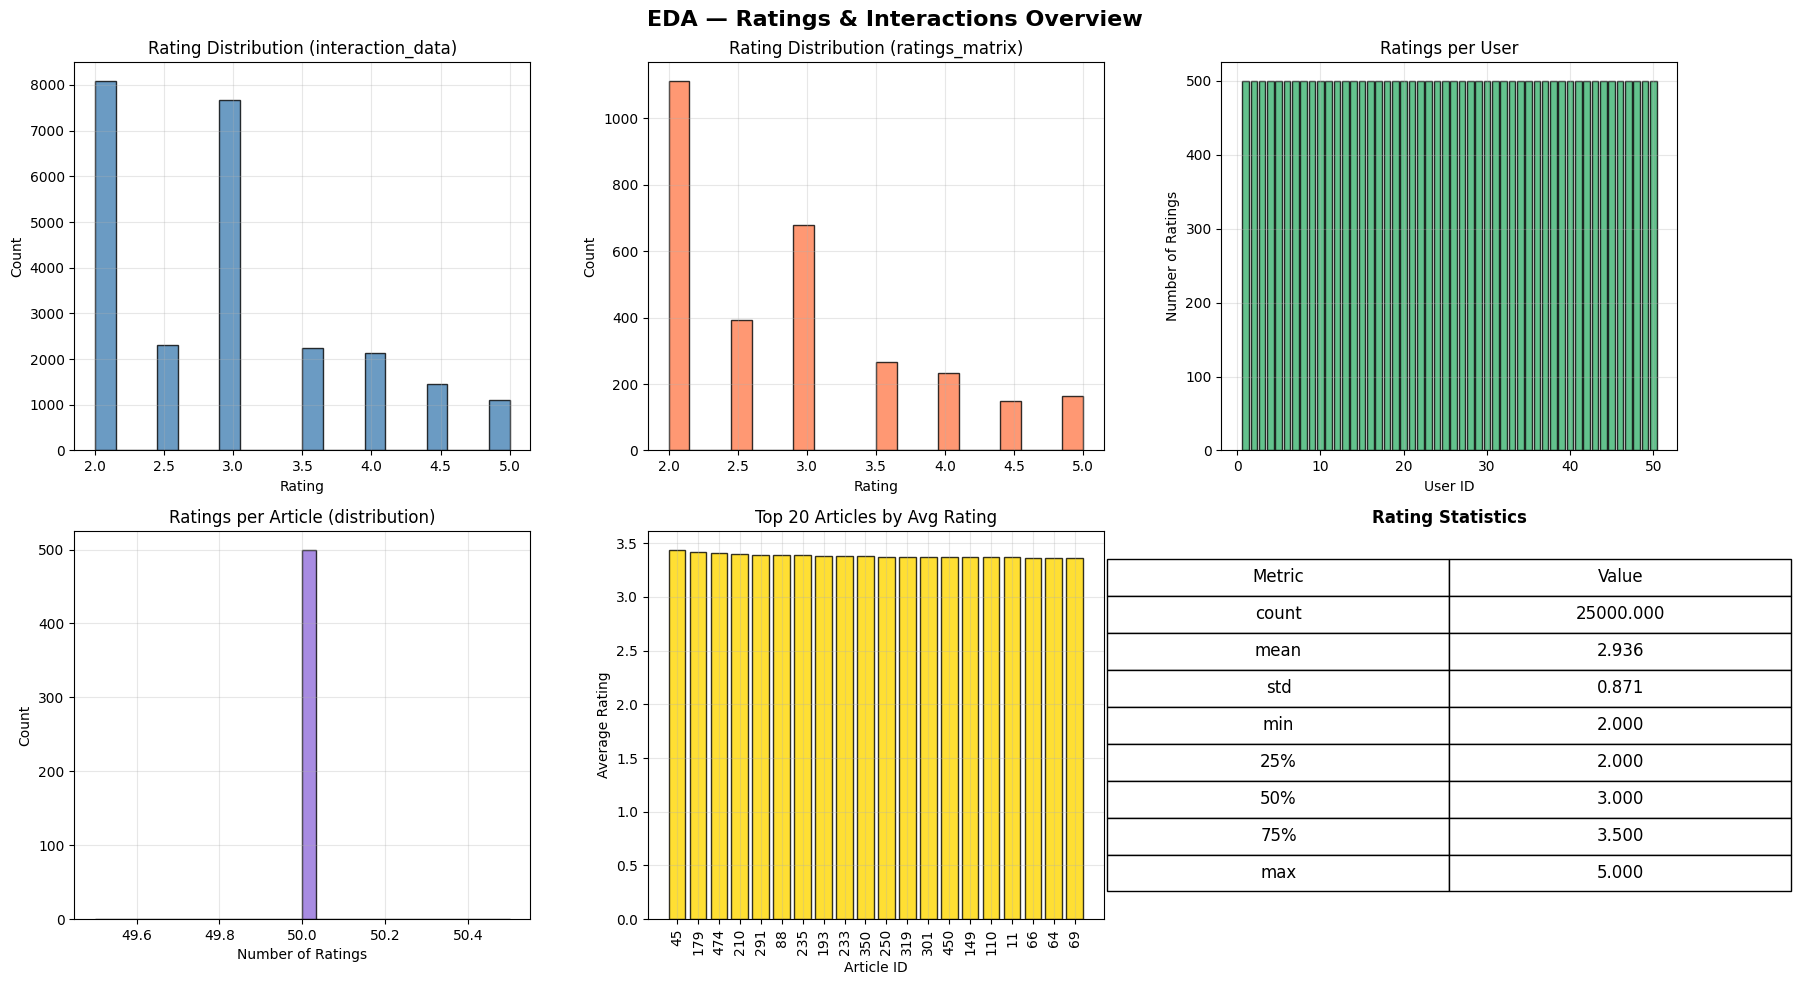


Unique users    : 50
Unique articles : 500
Total ratings   : 25000
Rating range    : 2.0 → 5.0
Sparsity        : 0.0000


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Ratings & Interactions Overview', fontsize=16, fontweight='bold')

# 1. Rating distribution — interaction_data
axes[0,0].hist(interaction_data['rating'], bins=20,
               color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].set_title('Rating Distribution (interaction_data)')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')
axes[0,0].grid(True, alpha=0.3)

# 2. Rating distribution — ratings_matrix
axes[0,1].hist(ratings_matrix['rating'], bins=20,
               color='coral', edgecolor='black', alpha=0.8)
axes[0,1].set_title('Rating Distribution (ratings_matrix)')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('Count')
axes[0,1].grid(True, alpha=0.3)

# 3. Ratings per user
ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].bar(ratings_per_user.index, ratings_per_user.values,
              color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[0,2].set_title('Ratings per User')
axes[0,2].set_xlabel('User ID')
axes[0,2].set_ylabel('Number of Ratings')
axes[0,2].grid(True, alpha=0.3)

# 4. Ratings per article
ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color='mediumpurple', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Ratings per Article (distribution)')
axes[1,0].set_xlabel('Number of Ratings')
axes[1,0].set_ylabel('Count')
axes[1,0].grid(True, alpha=0.3)

# 5. Average rating per article (top 20)
avg_per_article = interaction_data.groupby('article_id')['rating'].mean().sort_values(ascending=False).head(20)
axes[1,1].bar(avg_per_article.index.astype(str), avg_per_article.values,
              color='gold', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Top 20 Articles by Avg Rating')
axes[1,1].set_xlabel('Article ID')
axes[1,1].set_ylabel('Average Rating')
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].grid(True, alpha=0.3)

# 6. Rating stats summary
stats = interaction_data['rating'].describe()
axes[1,2].axis('off')
table_data = [[k, f"{v:.3f}"] for k, v in stats.items()]
table = axes[1,2].table(cellText=table_data,
                         colLabels=['Metric', 'Value'],
                         loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2)
axes[1,2].set_title('Rating Statistics', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique users    : {interaction_data['user_id'].nunique()}")
print(f"Unique articles : {interaction_data['article_id'].nunique()}")
print(f"Total ratings   : {len(interaction_data)}")
print(f"Rating range    : {interaction_data['rating'].min()} → {interaction_data['rating'].max()}")
print(f"Sparsity        : {1 - len(ratings_matrix)/(ratings_matrix['user_id'].nunique()*ratings_matrix['article_id'].nunique()):.4f}")

In [5]:
print("="*60)
print("MODEL 4: HYBRID MULTI-TOWER NEURAL NETWORK")
print("="*60)

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats
from tqdm import tqdm
import time, json, os
from datetime import timedelta
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)
os.makedirs('saved_models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU available: {gpus}")
else:
    print("No GPU — running on CPU")

# ── Feature column definitions ─────────────────────────────
USER_COLS = [c for c in interaction_data.columns
             if c.startswith('user_preference_')
             or c.startswith('user_type_')
             or (c.startswith('presentation_type_') and c.endswith('_x'))]

ITEM_COLS = [c for c in interaction_data.columns
             if c in ['Boring presentation','Graphics','Readability',
                      'Consistency','Images','Bullets','Text size',
                      'Text heavy','Tables','Agenda','Infographics',
                      'Positioning','Presentation length','General tips',
                      'Presentation skills','Powerpoint knowledge',
                      'tips and tricks','Explanation of the problem']
             or (c.startswith('presentation_type_') and c.endswith('_y'))
             or c.startswith('audience_type_')]

# Paper Table 2: exactly 12 core challenge categories
PAPER_PROBLEM_COLS = [
    'Boring presentation', 'Graphics', 'Readability', 'Consistency',
    'Images', 'Bullets', 'Text size', 'Text heavy', 'Tables', 'Agenda',
    'Infographics', 'Positioning'
]

print(f"User cols    : {len(USER_COLS)}")
print(f"Item cols    : {len(ITEM_COLS)}")
print(f"Problem cols : 12 (will be confirmed in next cell)")

MODEL 4: HYBRID MULTI-TOWER NEURAL NETWORK
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
User cols    : 31
Item cols    : 36
Problem cols : 12 (will be confirmed in next cell)


In [6]:
print("Feature engineering...")

df_h = interaction_data.copy()
df_h['timestamp'] = pd.to_datetime(df_h['timestamp'])
df_h = df_h.sort_values('timestamp').reset_index(drop=True)

# ── Cyclic time features ───────────────────────────────────
df_h['hour'] = df_h['timestamp'].dt.hour
df_h['dow']  = df_h['timestamp'].dt.dayofweek

df_h['hour_sin'] = np.sin(2 * np.pi * df_h['hour'] / 24)
df_h['hour_cos'] = np.cos(2 * np.pi * df_h['hour'] / 24)
df_h['day_sin']  = np.sin(2 * np.pi * df_h['dow']  / 7)
df_h['day_cos']  = np.cos(2 * np.pi * df_h['dow']  / 7)

# ── Hours since first interaction per user ─────────────────
first_ts = df_h.groupby('user_id')['timestamp'].transform('min')
df_h['hours_since_first'] = (
    (df_h['timestamp'] - first_ts).dt.total_seconds() / 3600
)

# ── Exponential decay on problem columns ───────────────────
decay = 0.01
df_h['decay_weight'] = np.exp(-decay * df_h['hours_since_first'] / 24)

for col in PAPER_PROBLEM_COLS:
    if col in df_h.columns:
        df_h[f'weighted_{col}'] = df_h[col] * df_h['decay_weight']
    else:
        print(f"WARNING: '{col}' not found — filling with 0")
        df_h[f'weighted_{col}'] = 0.0

TIME_COLS = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'hours_since_first']
PROB_COLS = [f'weighted_{c}' for c in PAPER_PROBLEM_COLS]

# Confirm exactly 12 — matches paper Table 5 shape (None, 12)
assert len(PROB_COLS) == 12, f"Expected 12, got {len(PROB_COLS)}"
print(f"PROB_COLS confirmed: {len(PROB_COLS)} columns")

# ── Normalize time + problem features ─────────────────────
scaler_h   = MinMaxScaler()
cols_scale = TIME_COLS + PROB_COLS
df_h[cols_scale] = scaler_h.fit_transform(df_h[cols_scale])

print(f"\nTime dim    : {len(TIME_COLS)}")
print(f"Problem dim : {len(PROB_COLS)}")
print(f"df_h shape  : {df_h.shape}")

Feature engineering...
PROB_COLS confirmed: 12 columns

Time dim    : 5
Problem dim : 12
df_h shape  : (25000, 95)


In [7]:
X_user = df_h[USER_COLS].values.astype(np.float32)
X_item = df_h[ITEM_COLS].values.astype(np.float32)
X_time = df_h[TIME_COLS].values.astype(np.float32)
X_prob = df_h[PROB_COLS].values.astype(np.float32)
y      = df_h['rating'].values.astype(np.float32)

idx = np.arange(len(y))
train_idx, temp_idx = train_test_split(idx, test_size=0.30, random_state=42)
val_idx,   test_idx = train_test_split(temp_idx, test_size=0.50, random_state=42)

def split(arr):
    return arr[train_idx], arr[val_idx], arr[test_idx]

Xu_tr, Xu_va, Xu_te = split(X_user)
Xi_tr, Xi_va, Xi_te = split(X_item)
Xt_tr, Xt_va, Xt_te = split(X_time)
Xp_tr, Xp_va, Xp_te = split(X_prob)
y_tr,  y_va,  y_te  = split(y)

print(f"Train : {len(y_tr):,} | Val : {len(y_va):,} | Test : {len(y_te):,}")
print(f"User  dim : {X_user.shape[1]}")
print(f"Item  dim : {X_item.shape[1]}")
print(f"Time  dim : {X_time.shape[1]}")
print(f"Prob  dim : {X_prob.shape[1]}")

Train : 17,500 | Val : 3,750 | Test : 3,750
User  dim : 31
Item  dim : 36
Time  dim : 5
Prob  dim : 12


In [8]:
def build_hybrid_model(user_dim, item_dim, time_dim, prob_dim,
                       user_units=128, item_units=256,
                       time_units=16,  prob_units=32,
                       dropout=0.3,    lr=5.17e-4):
    """
    Exact architecture from paper Table 5:
    User Tower  : Dense 128 → BN → Dropout → Embed 16
    Item Tower  : Dense 256 → BN → Dropout → Embed 16
    Time Tower  : Dense 16  → BN → Dropout
    Problem Tower: Dense 32 → BN → Dropout → Proj 32
    Concat → Dense 128 → BN → Dropout → Dense 32 → Output
    """
    reg = tf.keras.regularizers.l2(1e-5)

    # Inputs
    user_inp = Input(shape=(user_dim,), name='user_feat_input')
    item_inp = Input(shape=(item_dim,), name='item_feat_input')
    time_inp = Input(shape=(time_dim,), name='time_input')
    prob_inp = Input(shape=(prob_dim,), name='problem_seq_input')

    # User Tower
    u = layers.Dense(user_units, activation='relu',
                     kernel_regularizer=reg,
                     name='dense_user')(user_inp)
    u = layers.BatchNormalization(name='bn_user')(u)
    u = layers.Dropout(dropout, name='dropout_user')(u)
    u = layers.Dense(16, activation='relu',
                     name='dense_user_embed')(u)

    # Item Tower
    it = layers.Dense(item_units, activation='relu',
                      kernel_regularizer=reg,
                      name='dense_item')(item_inp)
    it = layers.BatchNormalization(name='bn_item')(it)
    it = layers.Dropout(dropout, name='dropout_item')(it)
    it = layers.Dense(16, activation='relu',
                      name='dense_item_embed')(it)

    # Time Tower
    t = layers.Dense(time_units, activation='relu',
                     name='dense_time')(time_inp)
    t = layers.BatchNormalization(name='bn_time')(t)
    t = layers.Dropout(dropout, name='dropout_time')(t)

    # Problem Tower
    p = layers.Dense(prob_units, activation='relu',
                     name='dense_problem_seq')(prob_inp)
    p = layers.BatchNormalization(name='bn_problem_seq')(p)
    p = layers.Dropout(dropout, name='dropout_problem_seq')(p)
    p = layers.Dense(32, activation='relu',
                     name='dense_problem_seq_proj')(p)

    # Fusion
    merged = layers.Concatenate(name='concat_embedding')([u, it, t, p])

    x = layers.Dense(128, activation='relu',
                     name='dense_combined')(merged)
    x = layers.BatchNormalization(name='bn_combined')(x)
    x = layers.Dropout(dropout, name='dropout_combined')(x)
    x = layers.Dense(32, activation='relu',
                     name='dense_hidden')(x)
    output = layers.Dense(1, activation='linear',
                          name='output')(x)

    model = Model(
        inputs=[user_inp, item_inp, time_inp, prob_inp],
        outputs=output,
        name='HybridMultiTower'
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss='mse',
        metrics=['mae']
    )
    return model

# Preview
preview = build_hybrid_model(
    user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
    time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS)
)
preview.summary()
print(f"\nTotal parameters: {preview.count_params():,}")

I0000 00:00:1774687052.000815      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774687052.006791      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "HybridMultiTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_feat_input     │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_feat_input     │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ problem_seq_input   │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_user (Dense)  │ (None, 128)       │      4,096 │ user_feat_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_item (Dense)  │ (None, 256)       │      9,472 │ item_feat_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_input          │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_problem_seq   │ (None, 32)        │        416 │ problem_seq_inpu… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_user             │ (None, 128)       │        512 │ dense_user[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_item             │ (None, 256)       │      1,024 │ dense_item[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_time (Dense)  │ (None, 16)        │         96 │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_problem_seq      │ (None, 32)        │        128 │ dense_problem_se… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_user        │ (None, 128)       │          0 │ bn_user[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_item        │ (None, 256)       │          0 │ bn_item[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_time             │ (None, 16)        │         64 │ dense_time[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_problem_seq │ (None, 32)        │          0 │ bn_problem_seq[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_user_embed    │ (None, 16)        │      2,064 │ dropout_user[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_item_embed    │ (None, 16)        │      4,112 │ dropout_item[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_time        │ (None, 16)        │          0 │ bn_time[0][0]   

 Total params: 38,081 (148.75 KB)

 Trainable params: 36,961 (144.38 KB)

 Non-trainable params: 1,120 (4.38 KB)


Total parameters: 38,081


In [9]:
print("="*60)
print("STEP 1: HYPERPARAMETER TUNING")
print("="*60)

configs_h = [
    {'user_u':128, 'item_u':256, 'drop':0.3, 'lr':5.17e-4},
    {'user_u':128, 'item_u':256, 'drop':0.2, 'lr':1e-3},
    {'user_u':64,  'item_u':256, 'drop':0.3, 'lr':5e-4},
    {'user_u':128, 'item_u':128, 'drop':0.2, 'lr':1e-3},
    {'user_u':128, 'item_u':256, 'drop':0.4, 'lr':5e-4},
]

tune_results_h = []

for i, cfg in enumerate(configs_h):
    print(f"\nConfig {i+1}/{len(configs_h)}: {cfg}")

    m = build_hybrid_model(
        user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
        time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS),
        user_units=cfg['user_u'], item_units=cfg['item_u'],
        dropout=cfg['drop'],      lr=cfg['lr']
    )

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    h = m.fit(
        [Xu_tr, Xi_tr, Xt_tr, Xp_tr], y_tr,
        validation_data=([Xu_va, Xi_va, Xt_va, Xp_va], y_va),
        epochs=20, batch_size=256,
        callbacks=[es], verbose=1
    )

    bvl   = min(h.history['val_loss'])
    bvmae = min(h.history['val_mae'])
    btl   = min(h.history['loss'])
    btmae = min(h.history['mae'])
    ep    = len(h.history['loss'])

    print(f"  Epochs     : {ep}")
    print(f"  Train loss : {btl:.4f} | Val loss : {bvl:.4f}")
    print(f"  Train MAE  : {btmae:.4f} | Val MAE  : {bvmae:.4f}")

    tune_results_h.append({
        'config'    : cfg,
        'val_loss'  : bvl,
        'val_mae'   : bvmae,
        'train_loss': btl,
        'train_mae' : btmae,
        'epochs'    : ep
    })

print("\n" + "="*60)
print("TUNING SUMMARY")
print("="*60)
print(f"{'Cfg':<5}{'Train Loss':>12}{'Val Loss':>10}"
      f"{'Train MAE':>11}{'Val MAE':>9}{'Epochs':>7}")
print("-"*55)
for i, r in enumerate(tune_results_h):
    print(f"  {i+1:<4}{r['train_loss']:>12.4f}{r['val_loss']:>10.4f}"
          f"{r['train_mae']:>11.4f}{r['val_mae']:>9.4f}{r['epochs']:>7}")

best_h     = min(tune_results_h, key=lambda x: x['val_mae'])
best_cfg_h = best_h['config']
print(f"\nBest config  : {best_cfg_h}")
print(f"Best val MAE : {best_h['val_mae']:.4f}")

STEP 1: HYPERPARAMETER TUNING

Config 1/5: {'user_u': 128, 'item_u': 256, 'drop': 0.3, 'lr': 0.000517}
Epoch 1/20


I0000 00:00:1774687058.076382      75 service.cc:152] XLA service 0x52e13840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774687058.076415      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774687058.076419      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774687058.997335      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


47/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.6318 - mae: 2.9512

I0000 00:00:1774687063.887563      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


69/69 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - loss: 9.4470 - mae: 2.7301 - val_loss: 5.9304 - val_mae: 2.2827
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7412 - mae: 1.0391 - val_loss: 2.7273 - val_mae: 1.4489
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0050 - mae: 0.7856 - val_loss: 1.3131 - val_mae: 0.9041
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8164 - mae: 0.7013 - val_loss: 0.6984 - val_mae: 0.6299
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6917 - mae: 0.6490 - val_loss: 0.4558 - val_mae: 0.4987
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6260 - mae: 0.6135 - val_loss: 0.3597 - val_mae: 0.4484
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5633 - mae: 0.5841 - val_loss: 0.3170 - val_mae: 0.4318
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5126 - mae: 0.5548 - val_loss: 0.3096 - val_mae: 0.4342
Epoch 9/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4852 - mae: 0.5368 - 

In [10]:
print("="*60)
print("STEP 2: TRAINING FINAL MODEL")
print("="*60)

hybrid_model = build_hybrid_model(
    user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
    time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS),
    user_units=best_cfg_h['user_u'],
    item_units=best_cfg_h['item_u'],
    dropout   =best_cfg_h['drop'],
    lr        =best_cfg_h['lr']
)

callbacks_h = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('saved_models/hybrid_best.keras',
                    monitor='val_loss',
                    save_best_only=True, verbose=1)
]

start = time.time()
history_h = hybrid_model.fit(
    [Xu_tr, Xi_tr, Xt_tr, Xp_tr], y_tr,
    validation_data=([Xu_va, Xi_va, Xt_va, Xp_va], y_va),
    epochs=200,
    batch_size=32,        # paper specifies batch_size=32
    callbacks=callbacks_h,
    verbose=1
)
time_hybrid = time.time() - start

best_train_loss_h = min(history_h.history['loss'])
best_val_loss_h   = min(history_h.history['val_loss'])
best_train_mae_h  = min(history_h.history['mae'])
best_val_mae_h    = min(history_h.history['val_mae'])
total_epochs_h    = len(history_h.history['loss'])

print(f"\nTraining time : {str(timedelta(seconds=int(time_hybrid)))}")
print(f"Best val loss : {best_val_loss_h:.4f}")
print(f"Best val MAE  : {best_val_mae_h:.4f}")

STEP 2: TRAINING FINAL MODEL
Epoch 1/200
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.1643 - mae: 1.0835
Epoch 1: val_loss improved from inf to 0.35920, saving model to saved_models/hybrid_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 2.1623 - mae: 1.0829 - val_loss: 0.3592 - val_mae: 0.4320 - learning_rate: 0.0010
Epoch 2/200
535/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4752 - mae: 0.5323
Epoch 2: val_loss improved from 0.35920 to 0.33483, saving model to saved_models/hybrid_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4745 - mae: 0.5318 - val_loss: 0.3348 - val_mae: 0.4080 - learning_rate: 0.0010
Epoch 3/200
532/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3856 - mae: 0.4751
Epoch 3: val_loss improved from 0.33483 to 0.33117, saving model to saved_models/hybrid_best.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3853 - mae: 0.4748 - val_loss: 0.3312 - val_mae: 0.3905 - learning_rate: 0.0010
Epoch 4/200
542/547 ━━━━━━━━━━━━━━━━

In [11]:
print("="*60)
print("STEP 3: TEST SET EVALUATION")
print("="*60)

y_pred_h4 = hybrid_model.predict(
    [Xu_te, Xi_te, Xt_te, Xp_te],
    batch_size=512, verbose=1
).flatten()

y_pred_h4 = np.clip(y_pred_h4, 2.0, 5.0)

mae_h4  = mean_absolute_error(y_te, y_pred_h4)
mse_h4  = mean_squared_error(y_te, y_pred_h4)
rmse_h4 = np.sqrt(mse_h4)

print("\n" + "="*65)
print("  MODEL 4: HYBRID MULTI-TOWER — FINAL RESULTS")
print("="*65)
print(f"  MAE  : {mae_h4:.4f}   (paper: 0.11)")
print(f"  MSE  : {mse_h4:.4f}   (paper: 0.033)")
print(f"  RMSE : {rmse_h4:.4f}   (paper: 0.18)")
print(f"  Time : {str(timedelta(seconds=int(time_hybrid)))}")
print(f"\n  Beats paper? {'YES' if mae_h4 < 0.11 else 'NO'}")
print("="*65)

STEP 3: TEST SET EVALUATION
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step

  MODEL 4: HYBRID MULTI-TOWER — FINAL RESULTS
  MAE  : 0.0734   (paper: 0.11)
  MSE  : 0.0259   (paper: 0.033)
  RMSE : 0.1611   (paper: 0.18)
  Time : 0:07:23

  Beats paper? YES


In [12]:
print("="*60)
print("STEP 4: 5-FOLD CROSS-VALIDATION")
print("="*60)

# Combine train + val for CV
X_all_user = np.vstack([Xu_tr, Xu_va])
X_all_item = np.vstack([Xi_tr, Xi_va])
X_all_time = np.vstack([Xt_tr, Xt_va])
X_all_prob = np.vstack([Xp_tr, Xp_va])
y_all      = np.concatenate([y_tr, y_va])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_mae_hybrid   = []
fold_mae_baseline = []

print(f"Running 5-fold CV on {len(y_all):,} samples...\n")

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_all_user)):
    print(f"--- Fold {fold+1}/5 ---")

    m = build_hybrid_model(
        user_dim=len(USER_COLS), item_dim=len(ITEM_COLS),
        time_dim=len(TIME_COLS), prob_dim=len(PROB_COLS),
        user_units=best_cfg_h['user_u'],
        item_units=best_cfg_h['item_u'],
        dropout   =best_cfg_h['drop'],
        lr        =best_cfg_h['lr']
    )

    m.fit(
        [X_all_user[tr_idx], X_all_item[tr_idx],
         X_all_time[tr_idx], X_all_prob[tr_idx]],
        y_all[tr_idx],
        validation_data=(
            [X_all_user[va_idx], X_all_item[va_idx],
             X_all_time[va_idx], X_all_prob[va_idx]],
            y_all[va_idx]
        ),
        epochs=200,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=15,
                                  restore_best_weights=True, verbose=0)],
        verbose=0
    )

    preds = np.clip(
        m.predict([X_all_user[va_idx], X_all_item[va_idx],
                   X_all_time[va_idx], X_all_prob[va_idx]],
                  batch_size=512, verbose=0).flatten(),
        2.0, 5.0
    )

    fold_mae = mean_absolute_error(y_all[va_idx], preds)
    fold_mae_hybrid.append(fold_mae)

    # baseline: predict the mean rating every time
    baseline_pred = np.full_like(y_all[va_idx], y_all[va_idx].mean())
    fold_mae_baseline.append(mean_absolute_error(y_all[va_idx], baseline_pred))

    print(f"  Fold {fold+1} MAE: {fold_mae:.4f}\n")

fold_mae_hybrid   = np.array(fold_mae_hybrid)
fold_mae_baseline = np.array(fold_mae_baseline)
mean_cv_mae       = fold_mae_hybrid.mean()
std_cv_mae        = fold_mae_hybrid.std()

# ── Statistical significance tests (paper section 7.2) ────
t_stat,  p_val_t = stats.ttest_rel(fold_mae_hybrid, fold_mae_baseline)
w_stat,  p_val_w = stats.wilcoxon(fold_mae_hybrid,  fold_mae_baseline)

print("="*60)
print("5-FOLD CV RESULTS")
print("="*60)
print(f"Fold MAEs  : {[round(x,4) for x in fold_mae_hybrid]}")
print(f"Mean MAE   : {mean_cv_mae:.4f} ± {std_cv_mae:.4f}")
print(f"Paper MAE  : 0.11")
print(f"\nPaired t-test    : t={t_stat:.4f},  p={p_val_t:.4f}")
print(f"Wilcoxon test    : W={w_stat:.4f},  p={p_val_w:.4f}")
print(f"Significant?     : {'YES (p<0.05)' if p_val_t < 0.05 else 'NO'}")
print("="*60)

STEP 4: 5-FOLD CROSS-VALIDATION
Running 5-fold CV on 21,250 samples...

--- Fold 1/5 ---
  Fold 1 MAE: 0.0763

--- Fold 2/5 ---
  Fold 2 MAE: 0.0853

--- Fold 3/5 ---
  Fold 3 MAE: 0.0836

--- Fold 4/5 ---
  Fold 4 MAE: 0.0705

--- Fold 5/5 ---
  Fold 5 MAE: 0.0685

5-FOLD CV RESULTS
Fold MAEs  : [np.float64(0.0763), np.float64(0.0853), np.float64(0.0836), np.float64(0.0705), np.float64(0.0685)]
Mean MAE   : 0.0768 ± 0.0067
Paper MAE  : 0.11

Paired t-test    : t=-83.4207,  p=0.0000
Wilcoxon test    : W=0.0000,  p=0.0625
Significant?     : YES (p<0.05)


In [13]:
print("="*60)
print("STEP 5: UTILITY SCORING (paper Eq. 1–3)")
print("="*60)

# ── Raw predictions on test set ────────────────────────────
y_pred_raw = np.clip(
    hybrid_model.predict([Xu_te, Xi_te, Xt_te, Xp_te],
                          batch_size=512, verbose=0).flatten(),
    2.0, 5.0
)

test_df = df_h.iloc[test_idx].reset_index(drop=True)

# ── Audience boost ─────────────────────────────────────────
audience_cols = [c for c in ITEM_COLS if c.startswith('audience_type_')]
if len(audience_cols) > 0:
    article_aud    = Xi_te[:, [ITEM_COLS.index(c) for c in audience_cols]].argmax(axis=1)
    user_aud       = Xu_te[:, [USER_COLS.index(c) for c in audience_cols
                                if c in USER_COLS]].argmax(axis=1) \
                     if any(c in USER_COLS for c in audience_cols) \
                     else article_aud
    audience_boost = (article_aud == user_aud).astype(float)
else:
    audience_boost = np.zeros(len(test_df))

# ── Freshness score ────────────────────────────────────────
if 'hours_since_first' in test_df.columns:
    days_sub = test_df['hours_since_first'].values / 24.0
else:
    days_sub = np.zeros(len(test_df))

days_sub        = np.nan_to_num(days_sub, nan=0.0)
max_days        = days_sub.max() if days_sub.max() > 0 else 1.0
freshness_score = 1.0 - (days_sub / max_days)

# ── Inverse popularity ─────────────────────────────────────
if 'popularity' in test_df.columns:
    pop = np.nan_to_num(test_df['popularity'].values.astype(float), nan=1.0)
else:
    pop = np.ones(len(test_df))

inverse_popularity = 1.0 / (1.0 + pop)

# ── Paper Eq. 2 & 3 ───────────────────────────────────────
alpha, beta, gamma = 0.2, 0.3, 0.5

long_tail_boost = gamma * freshness_score + (1 - gamma) * inverse_popularity
utility_score   = (y_pred_raw
                   * (1 + alpha * audience_boost)
                   * (1 + beta  * long_tail_boost))

# ── Build results dataframe ────────────────────────────────
article_col = test_df['article_id'].values \
              if 'article_id' in test_df.columns \
              else np.arange(len(test_df))

results_df = pd.DataFrame({
    'article_id'       : article_col,
    'true_rating'      : y_te,
    'predicted_score'  : y_pred_raw,
    'days_since_rated' : days_sub,
    'utility_score'    : utility_score
})

# ── Table 7: top-10 before utility scoring ─────────────────
top10_before = results_df.nlargest(10, 'predicted_score').reset_index(drop=True)
top10_before.index += 1
print("\nTable 7 — Top-10 before utility scoring:")
print(top10_before[['article_id','true_rating',
                     'predicted_score','days_since_rated']].to_string())

# ── Table 8: top-10 after utility scoring ──────────────────
top10_after = results_df.nlargest(10, 'utility_score').reset_index(drop=True)
top10_after.index += 1
print("\nTable 8 — Top-10 after utility scoring:")
print(top10_after[['article_id','true_rating',
                    'predicted_score','days_since_rated',
                    'utility_score']].to_string())

STEP 5: UTILITY SCORING (paper Eq. 1–3)

Table 7 — Top-10 before utility scoring:
    article_id  true_rating  predicted_score  days_since_rated
1          306          5.0              5.0          0.028721
2          195          5.0              5.0          0.041521
3          295          5.0              5.0          0.006597
4           66          5.0              5.0          0.022852
5          233          5.0              5.0          0.032229
6           91          5.0              5.0          0.019832
7          362          5.0              5.0          0.025219
8           83          5.0              5.0          0.002675
9          179          5.0              5.0          0.014648
10         224          5.0              5.0          0.035629

Table 8 — Top-10 after utility scoring:
    article_id  true_rating  predicted_score  days_since_rated  utility_score
1          108          5.0         5.000000          0.007340       7.623659
2          184          5.0 

TABLE 10: BEYOND-ACCURACY EVALUATION METRICS

Metric               Ours    Paper       Diff
----------------------------------------------
Loss               0.0259   0.2122    -0.1863  ↓
Precision          1.0000   1.0000    +0.0000  ✓
Novelty            0.2653   0.4500    -0.1847  ↓
Serendipity        0.5000   0.4200    +0.0800  ↑
Diversity          0.4227   0.4900    -0.0673  ↓
Item Coverage      0.4840   0.1500    +0.3340  ↑

Saved: saved_models/hybrid_beyond_metrics.json


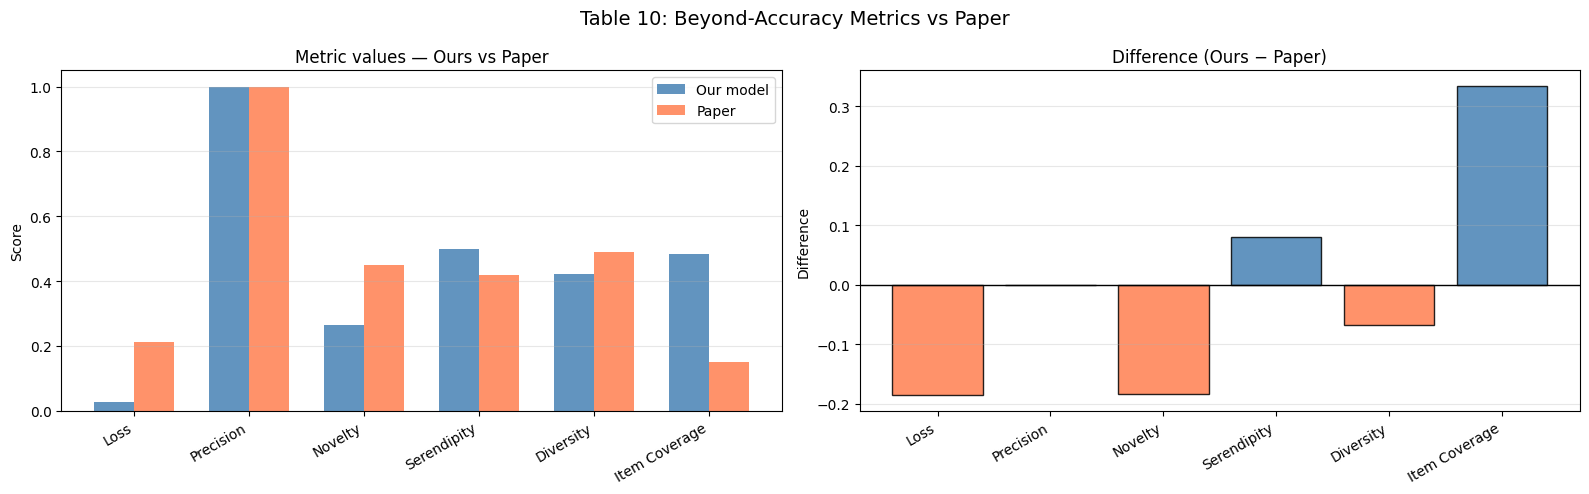

In [14]:
print("="*60)
print("TABLE 10: BEYOND-ACCURACY EVALUATION METRICS")
print("="*60)

K = 10
relevance_threshold = 3.5

# ── Precision@K ────────────────────────────────────────────
# Proportion of top-K recommended items that are actually relevant
top_k_df    = results_df.nlargest(K, 'utility_score')
precision_k = (top_k_df['true_rating'] >= relevance_threshold).mean()

# ── Novelty ────────────────────────────────────────────────
# How "unknown" recommended items are — rewards less popular items
pop_vals  = pop[top_k_df.index]
pop_norm  = pop_vals / (pop_vals.sum() + 1e-8)
novelty   = float(-np.sum(pop_norm * np.log2(pop_norm + 1e-8)) / K)

# ── Diversity ──────────────────────────────────────────────
# Average pairwise distance between recommended item feature vectors
item_vecs = Xi_te[top_k_df.index]
if len(top_k_df) > 1:
    sim_mat   = cosine_similarity(item_vecs)
    n         = len(top_k_df)
    mask      = ~np.eye(n, dtype=bool)
    diversity = float((1 - sim_mat[mask]).mean())
else:
    diversity = 0.0

# ── Serendipity ────────────────────────────────────────────
# Items that are BOTH relevant AND unexpected (dissimilar to avg item)
mean_item_vec = Xi_te.mean(axis=0, keepdims=True)
sims_to_mean  = cosine_similarity(item_vecs, mean_item_vec).flatten()
is_relevant   = (top_k_df['true_rating'].values >= relevance_threshold)
is_unexpected = (sims_to_mean < np.median(sims_to_mean))
serendipity   = float((is_relevant & is_unexpected).mean())

# ── Item Coverage ──────────────────────────────────────────
# Fraction of total catalog that ever gets recommended across all users
if 'user_id' in test_df.columns:
    all_recommended = set()
    total_items     = results_df['article_id'].nunique()
    for uid, grp in results_df.groupby(test_df['user_id'].values):
        top_k_user = grp.nlargest(K, 'utility_score')['article_id'].values
        all_recommended.update(top_k_user)
    item_coverage = len(all_recommended) / total_items
else:
    item_coverage = (top_k_df['article_id'].nunique()
                     / results_df['article_id'].nunique())

loss_val = float(mean_squared_error(y_te, y_pred_raw))

# ── Print comparison table ─────────────────────────────────
metrics = {
    'Loss'         : (loss_val,      0.2122),
    'Precision'    : (precision_k,   1.0),
    'Novelty'      : (novelty,       0.45),
    'Serendipity'  : (serendipity,   0.42),
    'Diversity'    : (diversity,     0.49),
    'Item Coverage': (item_coverage, 0.15),
}

print(f"\n{'Metric':<16} {'Ours':>8} {'Paper':>8} {'Diff':>10}")
print("-" * 46)
for name, (ours, paper) in metrics.items():
    diff = ours - paper
    flag = "  ✓" if abs(diff) < 0.05 else ("  ↑" if diff > 0 else "  ↓")
    print(f"{name:<16} {ours:>8.4f} {paper:>8.4f} {diff:>+10.4f}{flag}")

# ── Save everything ────────────────────────────────────────
beyond_metrics = {
    'loss'          : round(loss_val,      4),
    'precision_k'   : round(precision_k,   4),
    'novelty'       : round(novelty,       4),
    'serendipity'   : round(serendipity,   4),
    'diversity'     : round(diversity,     4),
    'item_coverage' : round(item_coverage, 4),
    'cv_mean_mae'   : round(float(mean_cv_mae), 4),
    'cv_std_mae'    : round(float(std_cv_mae),  4),
    't_stat'        : round(float(t_stat),      4),
    'p_value_t'     : round(float(p_val_t),     4),
    'p_value_w'     : round(float(p_val_w),     4),
}

with open('saved_models/hybrid_beyond_metrics.json', 'w') as f:
    json.dump(beyond_metrics, f, indent=2)

print("\nSaved: saved_models/hybrid_beyond_metrics.json")

# ── Bar chart comparing our metrics vs paper ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Table 10: Beyond-Accuracy Metrics vs Paper', fontsize=14)

names  = list(metrics.keys())
ours   = [v[0] for v in metrics.values()]
paper  = [v[1] for v in metrics.values()]
x      = np.arange(len(names))
width  = 0.35

axes[0].bar(x - width/2, ours,  width, label='Our model', color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, paper, width, label='Paper',     color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right')
axes[0].set_title('Metric values — Ours vs Paper')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Difference plot
diffs  = [o - p for o, p in zip(ours, paper)]
colors = ['steelblue' if d >= 0 else 'coral' for d in diffs]
axes[1].bar(names, diffs, color=colors, alpha=0.85, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=30, ha='right')
axes[1].set_title('Difference (Ours − Paper)')
axes[1].set_ylabel('Difference')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [15]:
os.makedirs('saved_models', exist_ok=True)

hybrid_model.save('saved_models/hybrid_model_final.keras')

hybrid_metrics = {
    'model'          : 'Hybrid Multi-Tower',
    'best_config'    : str(best_cfg_h),
    'total_epochs'   : total_epochs_h,
    'training_time'  : str(timedelta(seconds=int(time_hybrid))),
    'best_train_loss': round(best_train_loss_h, 4),
    'best_val_loss'  : round(best_val_loss_h,   4),
    'best_train_mae' : round(best_train_mae_h,  4),
    'best_val_mae'   : round(best_val_mae_h,    4),
    'test_MAE'       : round(float(mae_h4),     4),
    'test_MSE'       : round(float(mse_h4),     4),
    'test_RMSE'      : round(float(rmse_h4),    4),
    'paper_MAE'      : 0.11,
    'beats_paper'    : bool(mae_h4 < 0.11)
}

with open('saved_models/hybrid_metrics.json', 'w') as f:
    json.dump(hybrid_metrics, f, indent=2)

print("Saved:")
print("  saved_models/hybrid_model_final.keras")
print("  saved_models/hybrid_metrics.json")
print(f"\n  Beats paper? {'YES' if mae_h4 < 0.11 else 'NO'}")
print(f"  Paper MAE : 0.11 | Our MAE : {mae_h4:.4f}")

Saved:
  saved_models/hybrid_model_final.keras
  saved_models/hybrid_metrics.json

  Beats paper? YES
  Paper MAE : 0.11 | Our MAE : 0.0734


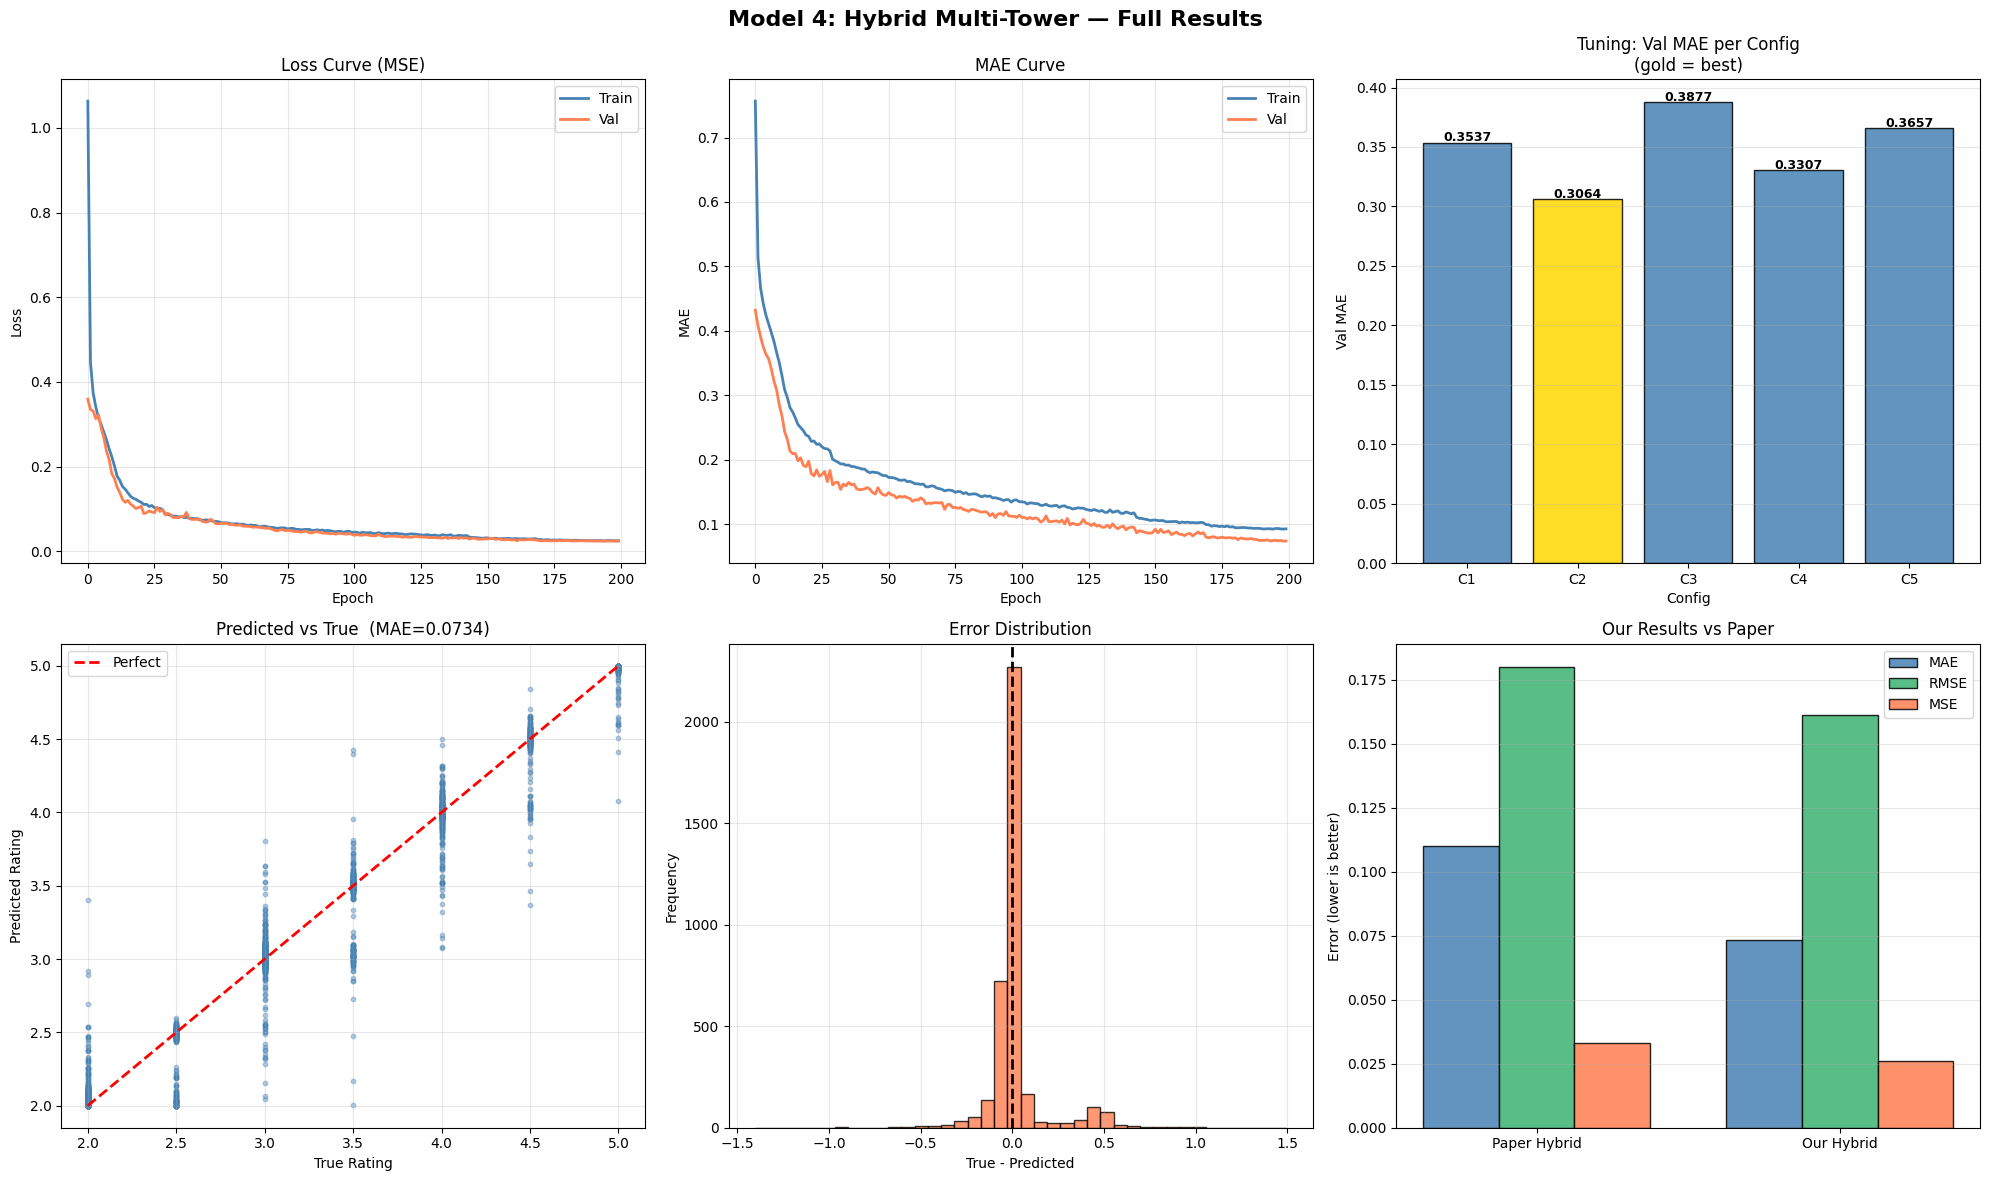


  FINAL SUMMARY — MODEL 4: HYBRID MULTI-TOWER
  Best config      : {'user_u': 128, 'item_u': 256, 'drop': 0.2, 'lr': 0.001}
  Epochs ran       : 200
  Training time    : 0:07:23
  Best train loss  : 0.0245
  Best val loss    : 0.0239
  Best train MAE   : 0.0923
  Best val MAE     : 0.0737
  Test MAE         : 0.0734   (paper: 0.11)
  Test MSE         : 0.0259   (paper: 0.033)
  Test RMSE        : 0.1611   (paper: 0.18)
  Beats paper?     : YES


In [16]:
%matplotlib inline

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model 4: Hybrid Multi-Tower — Full Results',
             fontsize=16, fontweight='bold')

# Loss curve
axes[0,0].plot(history_h.history['loss'],
               label='Train', linewidth=2, color='steelblue')
axes[0,0].plot(history_h.history['val_loss'],
               label='Val',   linewidth=2, color='coral')
axes[0,0].set_title('Loss Curve (MSE)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# MAE curve
axes[0,1].plot(history_h.history['mae'],
               label='Train', linewidth=2, color='steelblue')
axes[0,1].plot(history_h.history['val_mae'],
               label='Val',   linewidth=2, color='coral')
axes[0,1].set_title('MAE Curve')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('MAE')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Tuning comparison
config_labels = [f"C{i+1}" for i in range(len(tune_results_h))]
val_maes      = [r['val_mae'] for r in tune_results_h]
best_idx      = val_maes.index(min(val_maes))
bar_colors    = ['gold' if i == best_idx else 'steelblue'
                 for i in range(len(config_labels))]
bars = axes[0,2].bar(config_labels, val_maes,
                      color=bar_colors, edgecolor='black', alpha=0.85)
axes[0,2].set_title('Tuning: Val MAE per Config\n(gold = best)')
axes[0,2].set_xlabel('Config')
axes[0,2].set_ylabel('Val MAE')
axes[0,2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, val_maes):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Predicted vs True
axes[1,0].scatter(y_te, y_pred_h4,
                  alpha=0.4, s=10, color='steelblue')
axes[1,0].plot([2, 5], [2, 5], 'r--', linewidth=2, label='Perfect')
axes[1,0].set_title(f'Predicted vs True  (MAE={mae_h4:.4f})')
axes[1,0].set_xlabel('True Rating')
axes[1,0].set_ylabel('Predicted Rating')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Error distribution
errors_h = y_te - y_pred_h4
axes[1,1].hist(errors_h, bins=40,
               color='coral', edgecolor='black', alpha=0.8)
axes[1,1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1,1].set_title('Error Distribution')
axes[1,1].set_xlabel('True - Predicted')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

# Our results vs paper
x_pos    = np.arange(2)
w        = 0.25
axes[1,2].bar(x_pos - w, [0.11,  mae_h4],  width=w, label='MAE',
              color='steelblue',      edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos,     [0.18,  rmse_h4], width=w, label='RMSE',
              color='mediumseagreen', edgecolor='black', alpha=0.85)
axes[1,2].bar(x_pos + w, [0.033, mse_h4],  width=w, label='MSE',
              color='coral',          edgecolor='black', alpha=0.85)
axes[1,2].set_title('Our Results vs Paper')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(['Paper Hybrid', 'Our Hybrid'])
axes[1,2].set_ylabel('Error (lower is better)')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('saved_models/hybrid_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*65)
print("  FINAL SUMMARY — MODEL 4: HYBRID MULTI-TOWER")
print("="*65)
print(f"  Best config      : {best_cfg_h}")
print(f"  Epochs ran       : {total_epochs_h}")
print(f"  Training time    : {str(timedelta(seconds=int(time_hybrid)))}")
print(f"  Best train loss  : {best_train_loss_h:.4f}")
print(f"  Best val loss    : {best_val_loss_h:.4f}")
print(f"  Best train MAE   : {best_train_mae_h:.4f}")
print(f"  Best val MAE     : {best_val_mae_h:.4f}")
print(f"  Test MAE         : {mae_h4:.4f}   (paper: 0.11)")
print(f"  Test MSE         : {mse_h4:.4f}   (paper: 0.033)")
print(f"  Test RMSE        : {rmse_h4:.4f}   (paper: 0.18)")
print(f"  Beats paper?     : {'YES' if mae_h4 < 0.11 else 'NO'}")
print("="*65)